# Q3 — Incomplete Data (151 angles over 150 deg)
Load ground truth images and evaluate reconstructions for sliding angle windows.

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from skimage.transform import radon, iradon

In [23]:
import h5py
def load_mat_h5(path):
    try:
        with h5py.File(path,'r') as f:
            names = list(f.keys())
            for candidate in ['img','I','image','gt','phantom','X']:
                if candidate in f:
                    return np.squeeze(np.array(f[candidate]))
            if len(names)>0:
                return np.squeeze(np.array(f[names[0]]))
    except Exception:
        from scipy.io import loadmat
        data = loadmat(path)
        keys = [k for k in data.keys() if not k.startswith('__')]
        return np.squeeze(data[keys[0]])
im = load_mat_h5('data/assignmentMathImagingRecon_chestCT.mat')
im.shape

(512, 512)

In [18]:
import h5py

with h5py.File('data/assignmentMathImagingRecon_myPhantom.mat', 'r') as f:
    print("Keys inside MAT file:")
    print(list(f.keys()))

Keys inside MAT file:
['ans', 'imageMyPhantomAC']


In [31]:
import h5py
import numpy as np

def load_myphantom(path):
    with h5py.File(path, 'r') as f:
        data = np.array(f['imageMyPhantomAC'])

    data = np.squeeze(data).T   # transpose REQUIRED
    return data.astype(float)

im = load_myphantom('data/assignmentMathImagingRecon_myPhantom.mat')
print(im.shape)


(256, 256)


In [32]:
# ensure numeric type
im = im.astype(float)
im.shape

(256, 256)

In [33]:
def compute_best_window(gt, width=151):
    errs = []
    recs = []
    for start in range(0, 181):
        angs = (start + np.arange(0, width)) 
        s = radon(gt, theta=angs, circle=False)
        R = iradon(s, theta=angs, filter_name='ramp', circle=False)
        errs.append(np.linalg.norm(gt-R)/np.linalg.norm(gt))
        recs.append(R)
    errs = np.array(errs)
    return errs, recs

In [34]:
errs, recs = compute_best_window(im)
best_idx = np.argmin(errs)
best_idx, errs[best_idx]

(105, 0.27392860376972955)

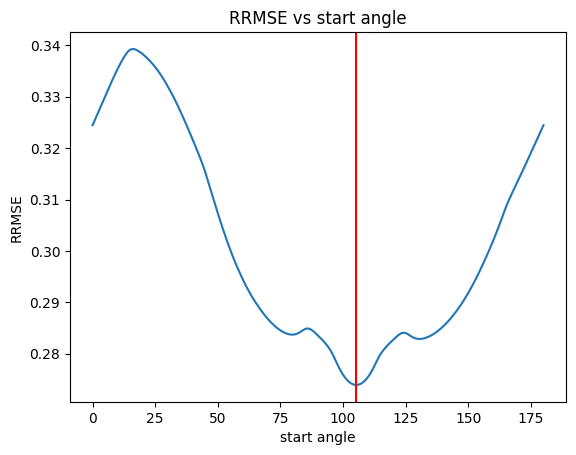

In [35]:
plt.plot(errs); plt.xlabel('start angle'); plt.ylabel('RRMSE'); plt.title('RRMSE vs start angle')
plt.axvline(best_idx, color='r')

Text(0.5, 1.0, 'Best reconstruction start=105')

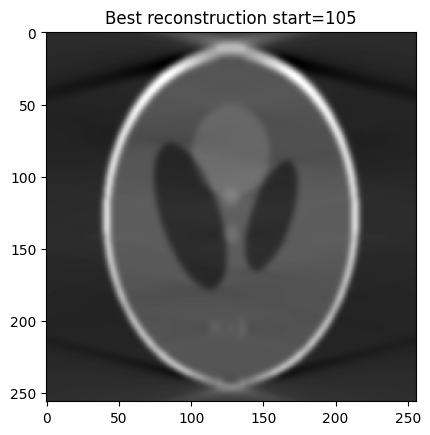

In [36]:
plt.figure(); plt.imshow(recs[best_idx], cmap='gray'); plt.title(f'Best reconstruction start={best_idx}')

ChestCT shape: (512, 512)
Phantom shape: (256, 256)

Evaluating dataset: chestCT
Best start theta0 = 67, best RRMSE = 0.265304


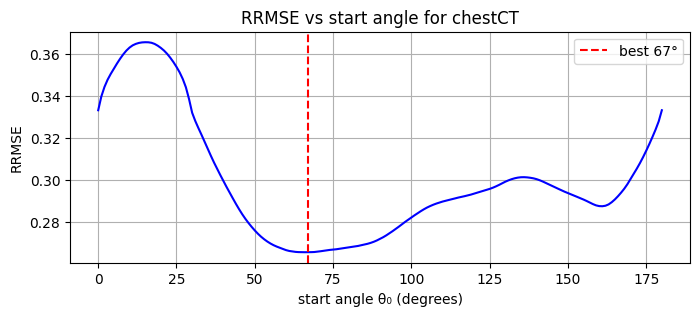

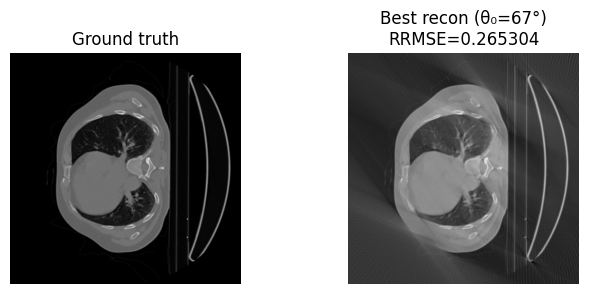

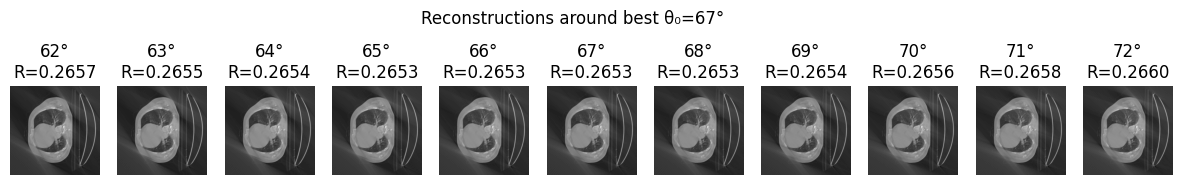


Evaluating dataset: myPhantom
Best start theta0 = 105, best RRMSE = 0.273929


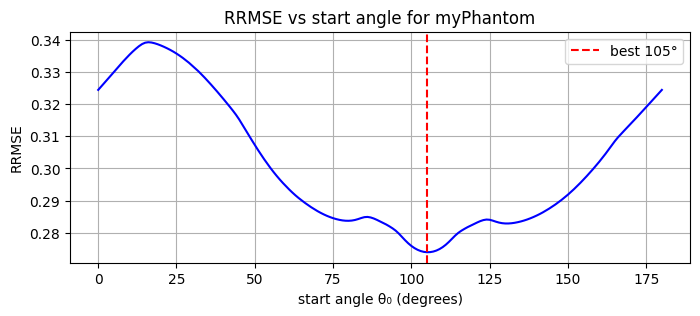

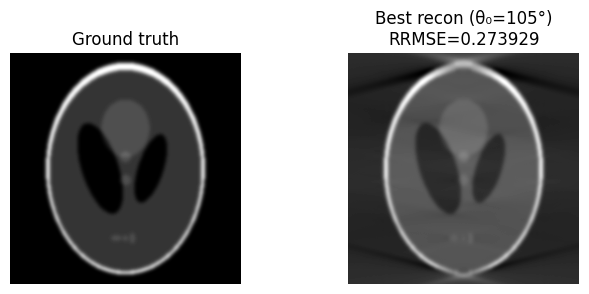

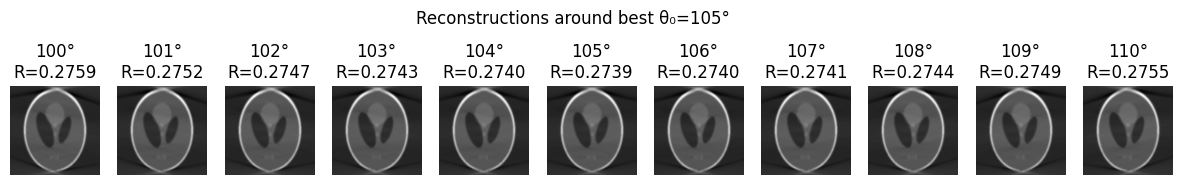

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import radon, iradon, resize
import scipy.io as sio


def compute_rrmse(gt, recon):
    """Relative root-mean-square error used in assignment:
       sqrt(sum((gt - recon)^2) / sum(gt^2))
    """
    gt = gt.astype(float)
    recon = recon.astype(float)
    num = np.sum((gt - recon)**2)
    denom = np.sum(gt**2)
    return np.sqrt(num / (denom + 1e-12))

def evaluate_dataset(gt_image,
                     start_theta_vals=np.arange(0, 181),
                     num_angles=151,
                     target_size=128,
                     iradon_filter='ramp'):
   
    gt = gt_image.astype(float)
    rrmse_curve = []
    recon_list = []
    for theta0 in start_theta_vals:
        angles = (np.arange(theta0, theta0 + num_angles) % 180).astype(float)
        sino = radon(gt, theta=angles, circle=False)      
        try:
            rec = iradon(sino, theta=angles, filter_name=iradon_filter, circle=False)
        except TypeError:       
            rec = iradon(sino, theta=angles, circle=False)
        
        if rec.shape != gt.shape:
            rec = resize(rec, gt.shape, preserve_range=True)
        recon_list.append(rec)
        rrmse_curve.append(compute_rrmse(gt, rec))
    rrmse_curve = np.array(rrmse_curve)
    best_idx = int(np.argmin(rrmse_curve))
    best_recon = recon_list[best_idx]
    return rrmse_curve, recon_list, best_idx, best_recon, gt

chestCT = load_mat_h5("data/assignmentMathImagingRecon_chestCT.mat")
myPhantom = load_myphantom("data/assignmentMathImagingRecon_myPhantom.mat")

datasets = {
    "chestCT": chestCT,
    "myPhantom": myPhantom
}

print("ChestCT shape:", chestCT.shape)
print("Phantom shape:", myPhantom.shape)

    

for name, img in datasets.items():
    print("\nEvaluating dataset:", name)
    theta0_vals = np.arange(0, 181, 1)  
    rrmse_curve, recon_list, best_idx, best_recon, gt_resized = evaluate_dataset(img,
                                                                                 start_theta_vals=theta0_vals,
                                                                                 num_angles=151,
                                                                                 target_size=128,
                                                                                 iradon_filter='ramp')
    print(f"Best start theta0 = {theta0_vals[best_idx]}, best RRMSE = {rrmse_curve[best_idx]:.6f}")


    plt.figure(figsize=(8,3))
    plt.plot(theta0_vals, rrmse_curve, '-b')
    plt.xlabel('start angle θ₀ (degrees)')
    plt.ylabel('RRMSE')
    plt.title(f'RRMSE vs start angle for {name}')
    plt.grid(True)
    plt.axvline(theta0_vals[best_idx], color='r', linestyle='--', label=f'best {theta0_vals[best_idx]}°')
    plt.legend()
    plt.show()

    
    plt.figure(figsize=(8,3))
    plt.subplot(1,2,1); plt.imshow(gt_resized, cmap='gray'); plt.title('Ground truth'); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(best_recon, cmap='gray'); plt.title(f'Best recon (θ₀={theta0_vals[best_idx]}°)\nRRMSE={rrmse_curve[best_idx]:.6f}'); plt.axis('off')
    plt.show()


    window = 5
    idxs = np.clip(np.arange(best_idx-window, best_idx+window+1), 0, len(theta0_vals)-1)
    plt.figure(figsize=(15,2.5))
    for k, idx in enumerate(idxs):
        plt.subplot(1, len(idxs), k+1)
        plt.imshow(recon_list[idx], cmap='gray'); plt.title(f'{theta0_vals[idx]}°\nR={rrmse_curve[idx]:.4f}'); plt.axis('off')
    plt.suptitle(f'Reconstructions around best θ₀={theta0_vals[best_idx]}°')
    plt.show()
